TODOs:

- Collect stats on how manay times a task is retried ---> helpful hint as to if your traces are "good/long enough"
- Analyze the graph to understand when speculating results and dispatching jobs is good.
  - This is when there is a single task that is taking a long time and choking the system and there is nothing waiting.
- Identify what tasks will benefit the most from being offloaded to ML-ConjunCT

In [90]:
import seaborn as sns
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sns.set_style("ticks")

In [91]:
datafile = '../task_stats_analysis.json'
with open(datafile, 'r') as f:
    data = json.load(f)

print(data.keys())

dict_keys(['running_times', 'waiting_times', 'waiting_count', 'running_count', 'completed_count'])


<Axes: ylabel='Percent'>

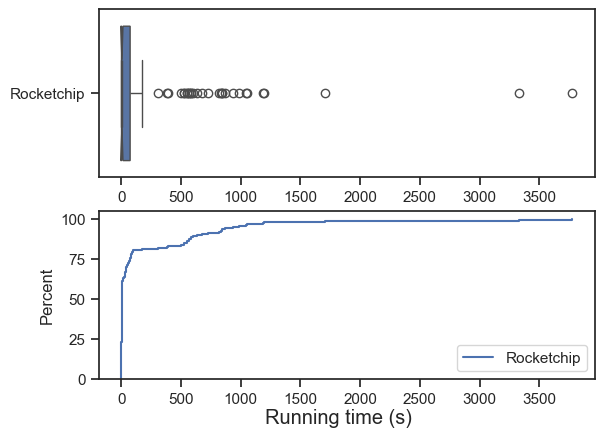

In [92]:
running_times = np.array(data["running_times"])
running_times = running_times / 1000.0
df = pd.DataFrame(running_times, columns=["Rocketchip"])
fig, (ax, ax2) = plt.subplots(2, 1)
fig.supxlabel("Running time (s)")
sns.boxplot(data=df, orient="h", notch=True, ax=ax)
sns.ecdfplot(data=df, ax=ax2, stat="percent")

<Axes: ylabel='Percent'>

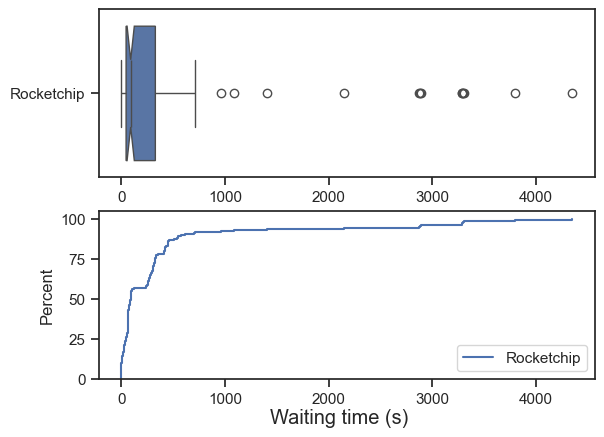

In [93]:
waiting_times = np.array(data["waiting_times"])
waiting_times = waiting_times / 1000.0
df = pd.DataFrame(waiting_times, columns=["Rocketchip"])
fig, (ax, ax2) = plt.subplots(2, 1)
fig.supxlabel("Waiting time (s)")
sns.boxplot(data=df, orient="h", notch=True, ax=ax)
sns.ecdfplot(data=df, ax=ax2, stat="percent")

[Text(0.5, 0, 'Sampling Epoch'), Text(0, 0.5, 'Count')]

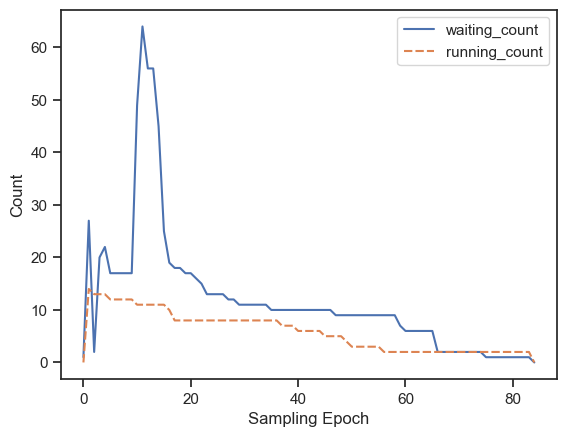

In [94]:
count_data = {}
for i, k in enumerate(data["waiting_count"]):
    count_data[i] = {
        "waiting_count": data["waiting_count"][k],
        "running_count": data["running_count"][k],
        # "completed_count": data["completed_count"][k],
    }

df = pd.DataFrame(count_data).T
sns.lineplot(data=df).set(xlabel="Sampling Epoch", ylabel="Count")